# Laplace Hessian Structure Comparison Tutorial

This notebook compares all `LaplaceWrapper` Hessian structures on the same MAP model and dataset:

- `diag`
- `fisher_diag`
- `lowrank_diag`
- `block_diag`
- `kron`
- `full`

The setup below increases MAP training quality, improves curvature estimation, and reports richer UQ metrics.


## What You Will See

1. Train a stronger deterministic MAP network with validation-based checkpointing.
2. Fit each Laplace Hessian structure from the same MAP weights.
3. Tune `prior_precision` per structure using validation NLL.
4. Compare methods with multiple metrics: RMSE, NLL, 95% coverage, interval width, and ID/OOD std ratio.
5. Visualize predictive bands and uncertainty profiles side-by-side.

Notes:
- `kron` and `full` are implemented natively in `deepuq` (no extra dependency).
- If unavailable, those entries are marked as skipped.


In [1]:
# Configure Python path so the notebook sees the local deepuq package
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd())
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = str(PROJECT_ROOT / 'src')
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)


In [2]:
import math
from copy import deepcopy

import matplotlib.pyplot as plt
import torch
from torch import optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, TensorDataset

from deepuq.models import MLP
from deepuq.methods import LaplaceWrapper
from deepuq.utils import set_seed

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
set_seed(11)
print('Running on', DEVICE)
print('Supported structures:', LaplaceWrapper.supported_hessian_structures())

def gaussian_nll(mean: torch.Tensor, var: torch.Tensor, target: torch.Tensor) -> float:
    var = var.clamp_min(1e-8)
    return (0.5 * (torch.log(2.0 * torch.tensor(math.pi)) + torch.log(var) + (target - mean) ** 2 / var)).mean().item()

def regression_metrics(mean: torch.Tensor, var: torch.Tensor, target: torch.Tensor) -> dict:
    rmse = torch.sqrt(torch.mean((mean - target) ** 2)).item()
    mae = torch.mean(torch.abs(mean - target)).item()
    nll = gaussian_nll(mean, var, target)
    std = torch.sqrt(var.clamp_min(1e-12))
    z = 1.96
    lower = mean - z * std
    upper = mean + z * std
    coverage95 = ((target >= lower) & (target <= upper)).float().mean().item()
    width95 = (upper - lower).mean().item()
    return {
        'rmse': rmse,
        'mae': mae,
        'nll': nll,
        'coverage95': coverage95,
        'width95': width95,
    }


Running on cpu
Supported structures: ('diag', 'fisher_diag', 'lowrank_diag', 'block_diag', 'kron', 'full')


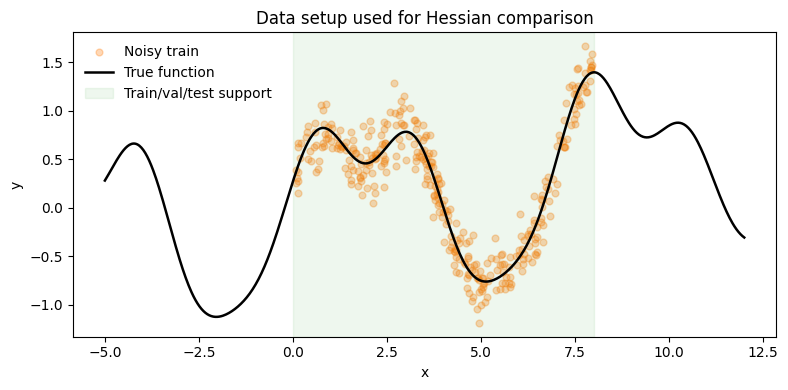

In [3]:
# Synthetic function and data generation
# Train/val/test are in [0, 8], while plotting extends to [-5, 12] to probe OOD uncertainty.
def target_fn(x: torch.Tensor) -> torch.Tensor:
    return (
        0.85 * torch.sin(0.9 * x)
        + 0.32 * torch.cos(1.7 * x)
        + 0.16 * torch.sin(2.6 * x - 0.3)
        + 0.05 * x
    )

n_train = 360
n_val = 180
n_test = 220
noise_std = 0.18
gen = torch.Generator().manual_seed(11)

x_train = torch.rand(n_train, 1, generator=gen) * 8.0
y_train_true = target_fn(x_train)
y_train = y_train_true + noise_std * torch.randn(y_train_true.shape, generator=gen)

x_val = torch.rand(n_val, 1, generator=gen) * 8.0
y_val_true = target_fn(x_val)

x_test = torch.rand(n_test, 1, generator=gen) * 8.0
y_test_true = target_fn(x_test)

x_plot = torch.linspace(-5.0, 12.0, 650).unsqueeze(-1)
y_plot_true = target_fn(x_plot)

id_mask = (x_plot.squeeze() >= 0.0) & (x_plot.squeeze() <= 8.0)
ood_mask = ~id_mask

# Separate loaders: one for MAP training, one smaller-batch loader for Laplace curvature estimation.
train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=72, shuffle=True)
curvature_loader = DataLoader(train_dataset, batch_size=2, shuffle=False)

plt.figure(figsize=(8, 4))
plt.scatter(x_train.numpy(), y_train.numpy(), s=24, alpha=0.30, color='tab:orange', label='Noisy train')
plt.plot(x_plot.numpy(), y_plot_true.numpy(), color='black', linewidth=1.8, label='True function')
plt.axvspan(0.0, 8.0, color='tab:green', alpha=0.08, label='Train/val/test support')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data setup used for Hessian comparison')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [4]:
# Train deterministic MAP baseline once (stronger optimization than the quick baseline).
map_model = MLP(input_dim=1, hidden_dims=[128, 128, 64], output_dim=1, p_drop=0.0).to(DEVICE)
optimizer = optim.AdamW(map_model.parameters(), lr=7e-4, weight_decay=2e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=1600, eta_min=1e-4)

best_val_mse = float('inf')
best_state = None

for epoch in range(1600):
    map_model.train()
    total = 0.0
    seen = 0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        pred = map_model(xb)
        loss = torch.nn.functional.mse_loss(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(map_model.parameters(), max_norm=2.0)
        optimizer.step()

        total += loss.item() * yb.numel()
        seen += yb.numel()

    scheduler.step()

    map_model.eval()
    with torch.no_grad():
        val_pred = map_model(x_val.to(DEVICE)).cpu()
    val_mse = torch.nn.functional.mse_loss(val_pred, y_val_true).item()

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_state = deepcopy(map_model.state_dict())

    if (epoch + 1) % 200 == 0:
        train_rmse = (total / max(seen, 1)) ** 0.5
        print(f'Epoch {epoch + 1:04d} | train RMSE={train_rmse:.4f} | val RMSE={best_val_mse**0.5:.4f}')

if best_state is None:
    raise RuntimeError('MAP training did not produce a valid checkpoint.')

map_model.load_state_dict(best_state)
map_model.eval()
with torch.no_grad():
    map_pred_plot = map_model(x_plot.to(DEVICE)).cpu()
    map_pred_test = map_model(x_test.to(DEVICE)).cpu()

map_test_mse = torch.nn.functional.mse_loss(map_pred_test, y_test_true).item()
map_test_rmse = map_test_mse ** 0.5
print(f'MAP best val RMSE: {best_val_mse**0.5:.5f}')
print(f'MAP test RMSE: {map_test_rmse:.5f} | MAP test MSE: {map_test_mse:.5f}')

map_state = {k: v.detach().cpu().clone() for k, v in map_model.state_dict().items()}


Epoch 0200 | train RMSE=0.1781 | val RMSE=0.0389


Epoch 0400 | train RMSE=0.1804 | val RMSE=0.0365


Epoch 0600 | train RMSE=0.1721 | val RMSE=0.0365


Epoch 0800 | train RMSE=0.1773 | val RMSE=0.0365


Epoch 1000 | train RMSE=0.1700 | val RMSE=0.0365


Epoch 1200 | train RMSE=0.1679 | val RMSE=0.0365


Epoch 1400 | train RMSE=0.1683 | val RMSE=0.0365


Epoch 1600 | train RMSE=0.1688 | val RMSE=0.0365
MAP best val RMSE: 0.03648
MAP test RMSE: 0.03658 | MAP test MSE: 0.00134


In [5]:
# Fit all Hessian structures with marginal-likelihood-tuned prior precision.
structures = ['diag', 'fisher_diag', 'lowrank_diag', 'block_diag', 'kron', 'full']
results = {}

for structure in structures:
    model = MLP(input_dim=1, hidden_dims=[128, 128, 64], output_dim=1, p_drop=0.0).to(DEVICE)
    model.load_state_dict(map_state)

    try:
        wrapper = LaplaceWrapper(
            model,
            likelihood='regression',
            hessian_structure=structure,
            subset_of_weights='last_layer',
            lowrank_rank=32,
            damping=1e-6,
            full_max_params=20000,
        )
        wrapper.fit(curvature_loader, prior_precision=1.0)
        optimal_prior = wrapper.optimize_prior_precision(n_steps=100, lr=0.1)
        print(f'{structure:12s} | optimized prior={optimal_prior:.4f}')

        mean_plot, var_plot = wrapper.predict(x_plot.to(DEVICE), n_samples=700)
        mean_test, var_test = wrapper.predict(x_test.to(DEVICE), n_samples=700)

        mean_plot = mean_plot.detach().cpu()
        var_plot = var_plot.detach().cpu().clamp_min(1e-12)
        std_plot = torch.sqrt(var_plot)

        mean_test = mean_test.detach().cpu()
        var_test = var_test.detach().cpu().clamp_min(1e-12)
        test_metrics = regression_metrics(mean_test, var_test, y_test_true)

        avg_std_id = std_plot.squeeze()[id_mask].mean().item()
        avg_std_ood = std_plot.squeeze()[ood_mask].mean().item()
        ood_id_ratio = avg_std_ood / max(avg_std_id, 1e-8)

        results[structure] = {
            'status': 'ok',
            'mean': mean_plot,
            'std': std_plot,
            'lower': mean_plot - 1.96 * std_plot,
            'upper': mean_plot + 1.96 * std_plot,
            'prior_precision': optimal_prior,
            'val_nll': 0.0,
            'val_rmse': 0.0,
            'test_rmse': test_metrics['rmse'],
            'test_mae': test_metrics['mae'],
            'test_nll': test_metrics['nll'],
            'coverage95': test_metrics['coverage95'],
            'width95': test_metrics['width95'],
            'avg_std_id': avg_std_id,
            'avg_std_ood': avg_std_ood,
            'ood_id_ratio': ood_id_ratio,
        }
    except Exception as exc:
        print(f'{structure:12s} | FAILED: {exc}')
        results[structure] = {'status': 'error', 'error': str(exc)}


diag         | optimized prior=30.4139


fisher_diag  | optimized prior=30.4139


lowrank_diag | optimized prior=0.0400


block_diag   | optimized prior=6.0750


kron         | optimized prior=2.0716


full         | optimized prior=6.0750


In [6]:
# Text summary table
header = (
    f"{'structure':12s} {'status':8s} {'prior':>7s} {'test_rmse':>10s} {'test_nll':>10s} "
    f"{'cov95':>8s} {'width95':>10s} {'std_ood/id':>11s}"
)
print(header)
print('-' * len(header))
for structure in structures:
    info = results[structure]
    if info['status'] != 'ok':
        print(f"{structure:12s} {'skipped':8s} {'-':>7s} {'-':>10s} {'-':>10s} {'-':>8s} {'-':>10s} {'-':>11s}")
        continue
    print(
        f"{structure:12s} {'ok':8s} "
        f"{info['prior_precision']:7.1f} "
        f"{info['test_rmse']:10.5f} {info['test_nll']:10.5f} "
        f"{info['coverage95']*100:7.2f}% {info['width95']:10.4f} {info['ood_id_ratio']:11.3f}"
    )

print()
print(f'MAP test RMSE baseline: {map_test_rmse:.5f}')


structure    status     prior  test_rmse   test_nll    cov95    width95  std_ood/id
-----------------------------------------------------------------------------------
diag         ok          30.4    0.03658   -0.37444  100.00%     1.0965       1.840
fisher_diag  ok          30.4    0.03658   -0.37444  100.00%     1.0965       1.840
lowrank_diag ok           0.0    0.03658   -0.71473  100.00%     0.7677      19.207
block_diag   ok           6.1    0.03658   -1.10805  100.00%     0.5027       4.258
kron         ok           2.1    0.03658    1.25249  100.00%     5.5633       1.840
full         ok           6.1    0.03658   -1.10805  100.00%     0.5027       4.258

MAP test RMSE baseline: 0.03658


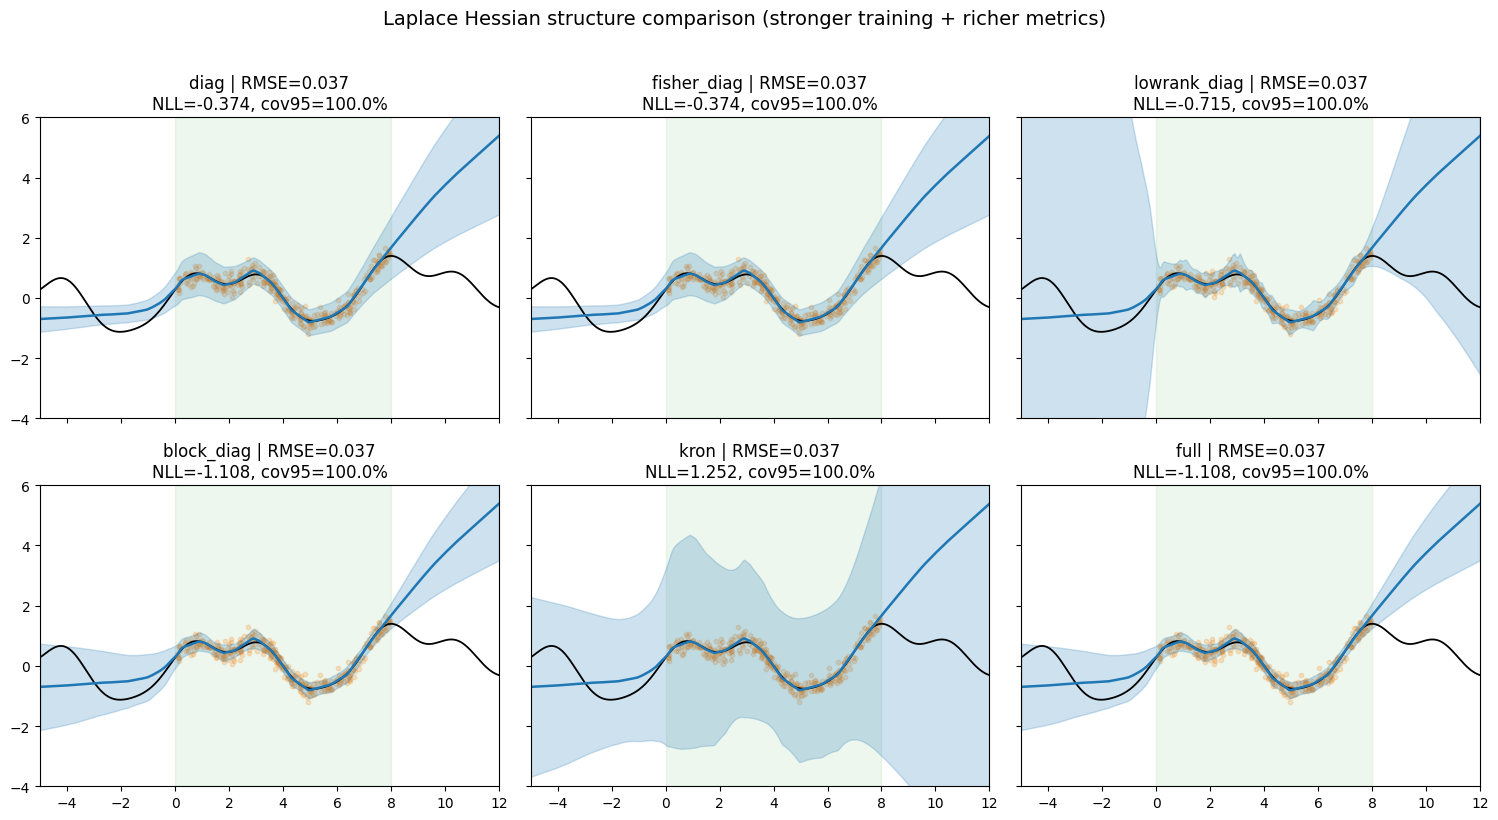

In [7]:
# Side-by-side predictive plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, structure in zip(axes, structures):
    info = results[structure]
    ax.scatter(x_train.numpy(), y_train.numpy(), s=10, alpha=0.20, color='tab:orange')
    ax.plot(x_plot.numpy(), y_plot_true.numpy(), color='black', linewidth=1.3)
    ax.axvspan(0.0, 8.0, color='tab:green', alpha=0.08)

    if info['status'] == 'ok':
        ax.plot(x_plot.numpy(), info['mean'].numpy(), color='tab:blue', linewidth=1.8)
        ax.fill_between(
            x_plot.squeeze().numpy(),
            info['lower'].squeeze().numpy(),
            info['upper'].squeeze().numpy(),
            color='tab:blue',
            alpha=0.22,
        )
        ax.set_title(
            f"{structure} | RMSE={info['test_rmse']:.3f}\n"
            f"NLL={info['test_nll']:.3f}, cov95={100*info['coverage95']:.1f}%"
        )
    else:
        ax.set_title(f"{structure} | skipped")
        ax.text(0.5, 0.5, info['error'].split(':')[0], ha='center', va='center', transform=ax.transAxes)

    ax.set_xlim(-5.0, 12.0)
    ax.set_ylim(-4.0, 6.0)

fig.suptitle('Laplace Hessian structure comparison (stronger training + richer metrics)', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


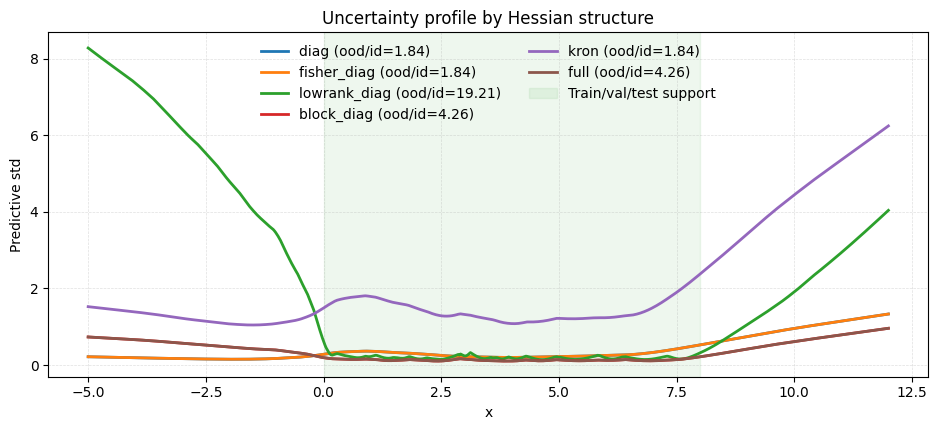

In [8]:
# Compare uncertainty profiles directly
plt.figure(figsize=(9.5, 4.4))
for structure in structures:
    info = results[structure]
    if info['status'] != 'ok':
        continue
    plt.plot(x_plot.numpy(), info['std'].numpy(), linewidth=2.0, label=f"{structure} (ood/id={info['ood_id_ratio']:.2f})")

plt.axvspan(0.0, 8.0, color='tab:green', alpha=0.08, label='Train/val/test support')
plt.xlabel('x')
plt.ylabel('Predictive std')
plt.title('Uncertainty profile by Hessian structure')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()
